In [1]:
import numpy as np
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [6]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])
df.dropna(inplace=True)

In [7]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [8]:
df.shape

(714, 3)

In [9]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [11]:
# Checking the accuracy and cross val score before any transformation
clf = DecisionTreeClassifier()

In [12]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [13]:
accuracy_score(y_test,y_pred)

0.6293706293706294

In [14]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6289319248826291)

In [51]:
kbin_age = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=10,encode='ordinal',strategy='quantile')

In [52]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [53]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [54]:
trf.named_transformers_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=10),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=10)}

In [55]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.67, 14.  , 18.  , 22.  , 25.  , 28.  , 31.  , 35.  , 42.  ,
              50.  , 80.  ])                                                ],
      dtype=object)

In [56]:
trf.named_transformers_['first']

,"n_bins n_bins: int or array-like of shape (n_features,), default=5The number of bins to produce. Raises ValueError if ``n_bins < 2``.",10
,"encode encode: {'onehot', 'onehot-dense', 'ordinal'}, default='onehot'Method used to encode the transformed result.- 'onehot': Encode the transformed result with one-hot encoding and return a sparse matrix. Ignored features are always stacked to the right.- 'onehot-dense': Encode the transformed result with one-hot encoding and return a dense array. Ignored features are always stacked to the right.- 'ordinal': Return the bin identifier encoded as an integer value.",'ordinal'
,"strategy strategy: {'uniform', 'quantile', 'kmeans'}, default='quantile'Strategy used to define the widths of the bins.- 'uniform': All bins in each feature have identical widths.- 'quantile': All bins in each feature have the same number of points.- 'kmeans': Values in each bin have the same nearest center of a 1D k-means cluster.For an example of the different strategies see::ref:`sphx_glr_auto_examples_preprocessing_plot_discretization_strategies.py`.",'quantile'
,"quantile_method quantile_method: {""inverted_cdf"", ""averaged_inverted_cdf"",""closest_observation"", ""interpolated_inverted_cdf"", ""hazen"",""weibull"", ""linear"", ""median_unbiased"", ""normal_unbiased""},default=""averaged_inverted_cdf""Method to pass on to np.percentile calculation when usingstrategy=""quantile"". Only `averaged_inverted_cdf` and `inverted_cdf`support the use of `sample_weight != None` when subsampling is notactive... versionadded:: 1.7.. versionchanged:: 1.9 The default value changed from `""linear""` to `""averaged_inverted_cdf""`.",'averaged_inverted_cdf'
,"dtype dtype: {np.float32, np.float64}, default=NoneThe desired data-type for the output. If None, output dtype isconsistent with input dtype. Only np.float32 and np.float64 aresupported... versionadded:: 0.24",None
,"subsample subsample: int or None, default=200_000Maximum number of samples, used to fit the model, for computationalefficiency.`subsample=None` means that all the training samples are used whencomputing the quantiles that determine the binning thresholds.Since quantile computation relies on sorting each column of `X` andthat sorting has an `n log(n)` time complexity,it is recommended to use subsampling on datasets with avery large number of samples... versionchanged:: 1.3 The default value of `subsample` changed from `None` to `200_000` when `strategy=""quantile""`... versionchanged:: 1.5 The default value of `subsample` changed from `None` to `200_000` when `strategy=""uniform""` or `strategy=""kmeans""`.",200000
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for subsampling.Pass an int for reproducible results across multiple function calls.See the `subsample` parameter for more details.See :term:`Glossary <random_state>`... versionadded:: 1.1",None
Name,Type,Value
"bin_edges_ bin_edges_: ndarray of ndarray of shape (n_features,)The edges of each bin. Contain arrays of varying shapes ``(n_bins_, )``Ignored features will have empty arrays.","ndarray[object](1,)","[array([ 0.67, 14. , 18. , 22. , 25. , 28. , 31. , 35. , 42. , 50. , 80. ]) ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Age']
"n_bins_ n_bins_: ndarray of shape (n_features,), dtype=np.int64Number of bins per feature. Bins whose width are too small(i.e., <= 1e-8) are removed with a warning.","ndarray[int64](1,)",[10]


In [57]:
trf.named_transformers_['first'].n_bins

10

In [58]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.    ,   7.7417,   7.8958,   8.6625,  12.35  ,  15.5   ,
               25.9292,  27.9   ,  39.6875,  78.2667, 512.3292])         ],
      dtype=object)

In [59]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [60]:
output

,age,age_trf,fare,fare_trf
387,36.0,7.0,13.0000,4.0
685,25.0,4.0,41.5792,8.0
20,35.0,7.0,26.0000,6.0
331,45.5,8.0,28.5000,7.0
396,31.0,6.0,7.8542,1.0
...,...,...,...,...
883,28.0,5.0,10.5000,3.0
238,19.0,2.0,10.5000,3.0
789,46.0,8.0,79.2000,9.0
704,26.0,4.0,7.8542,1.0


In [61]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [62]:
output.sample(5)
# How to Read the Transformation
# Look at the first row (index 525) to understand how a single data point moved through this pipeline:

# The passenger's original age is 40.5.

# The transformer determined that 40.5 falls into the specific mathematical interval of (35.0, 42.0]. The parenthesis ( means strictly greater than 35.0, and the square bracket ] means less than or equal to 42.0.
# Because it falls into this specific bucket, the scikit-learn transformer assigned it the ordinal category of 7.0 in the age_trf column.
# This table acts as a verification step. It proves that your ColumnTransformer successfully replaced infinite continuous possibilities (like any age or fare amount) with a fixed number of grouped integer categories based on the quantile boundaries it learned from the training data.

,age,age_trf,fare,fare_trf,age_labels,fare_labels
838,32.0,6.0,56.4958,8.0,"(31.0, 35.0]","(39.688, 78.267]"
784,25.0,4.0,7.0500,0.0,"(22.0, 25.0]","(0.0, 7.742]"
244,30.0,5.0,7.2250,0.0,"(28.0, 31.0]","(0.0, 7.742]"
635,28.0,5.0,13.0000,4.0,"(25.0, 28.0]","(12.35, 15.5]"
764,16.0,1.0,7.7750,1.0,"(14.0, 18.0]","(7.742, 7.896]"


In [63]:
# Checking the accuracy after binning 
# first I assinged 10 bins , now lets change it to 15 and see the results if they can imporve more 
#
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [64]:
accuracy_score(y_test,y_pred2)
# choosing 10 bins the accuracy score was 69 percent , making 15 bins dropped it down to 66 percent 

0.6993006993006993

In [65]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6372848200312988)

In [68]:
# You can also create ur own custom Discretization function 
# this function is created so u only change values and it gives plots too

def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Age Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("Age After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Fare Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare After")

    plt.show()
    

0.6274843505477308


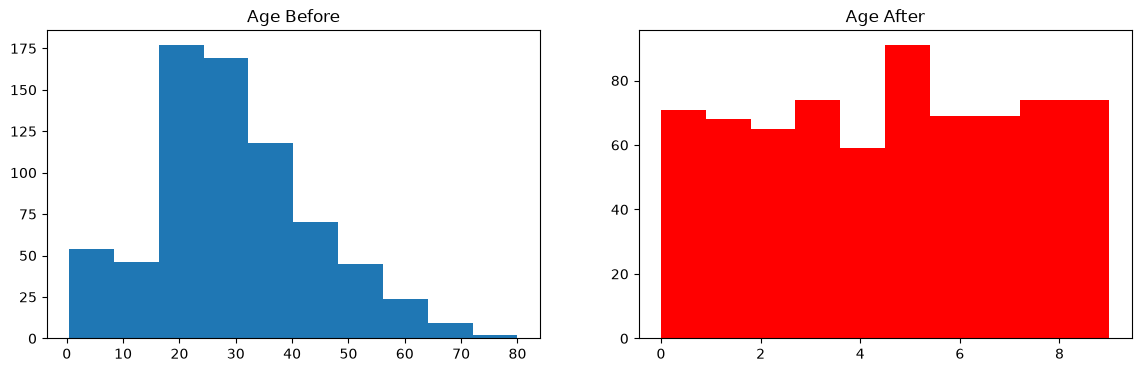

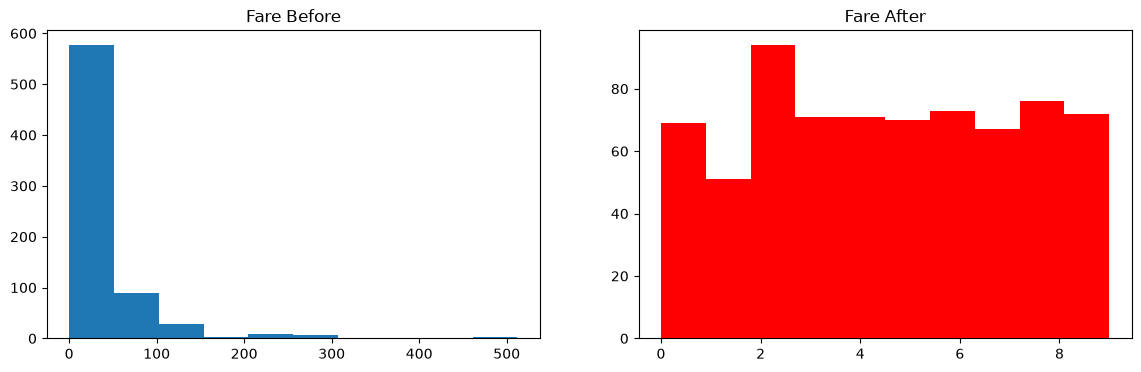

In [69]:
# checking different binnings 
discretize(10,'quantile')

0.6289319248826291


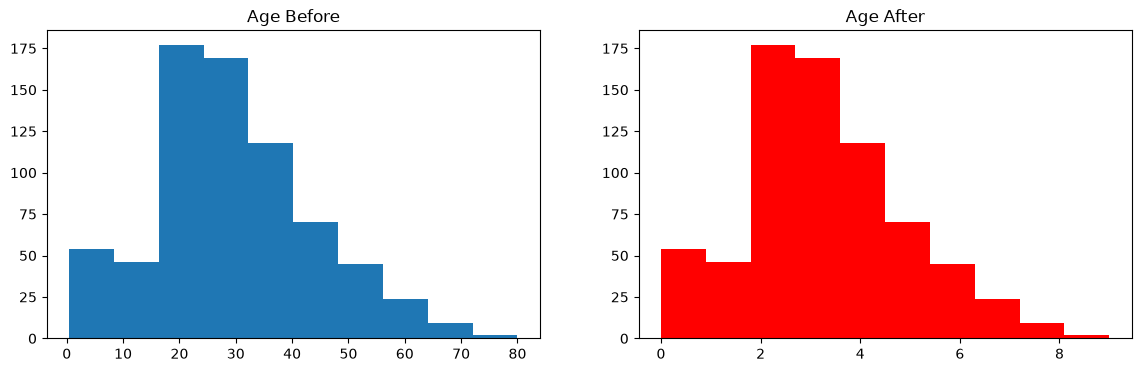

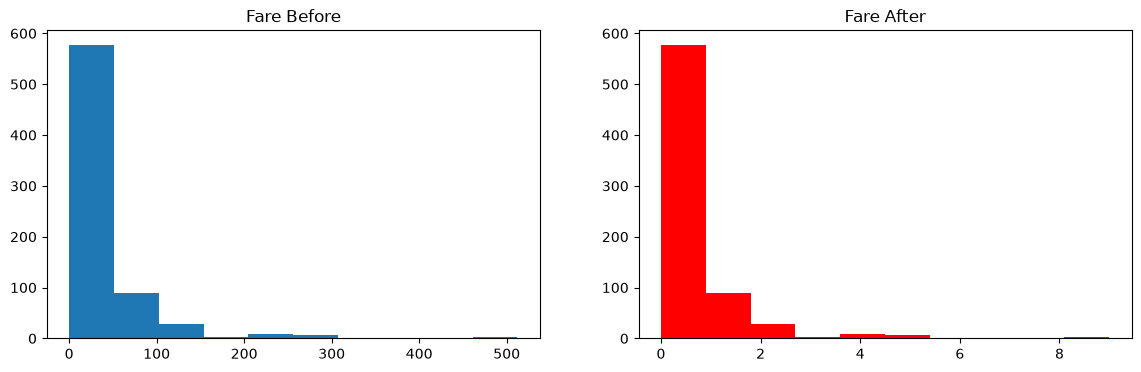

In [70]:
discretize(10,'uniform')

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1428: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


0.6288536776212832


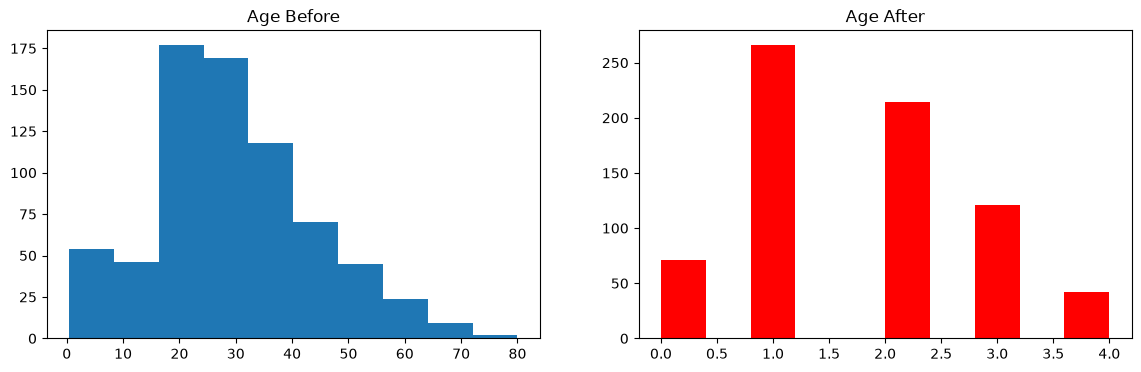

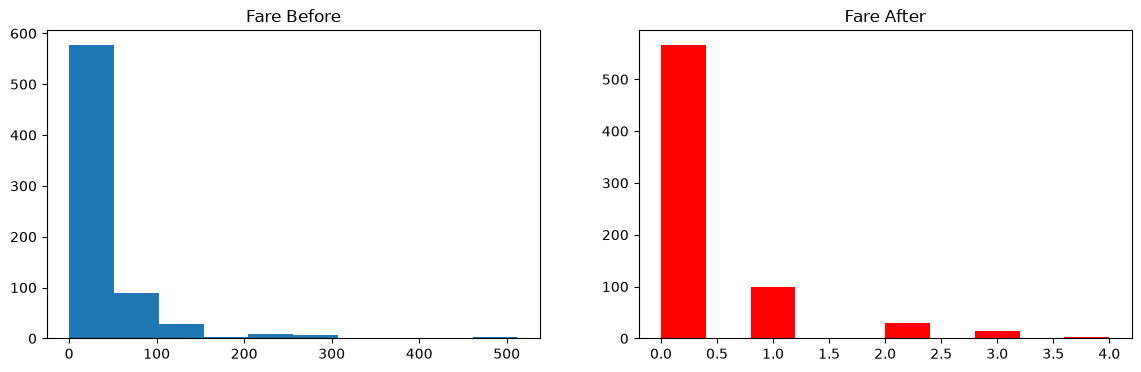

In [72]:
discretize(5,'kmeans')

In [ ]:
# creating custom bining function have no class in scikit learn , u have to use pandas for that 